In [5]:
import os

import matplotlib.pyplot as plt
import pandas as pd


In [6]:
STAT_PATH = "../experiments"
SPEED_STATISTICS_NAME = os.path.join("exp", "speed_statistics")
EXP_NAME = "run_"
MAJOR_BIN_WIDTH = 50.0
BARS_PER_MAJOR_BIN = 3
POWER_BIN_WIDTH = MAJOR_BIN_WIDTH / BARS_PER_MAJOR_BIN


In [7]:
def read_hosts_power(file_path):
    df = pd.read_csv(file_path, header=None, names=["host_power_gflops"])
    return df["host_power_gflops"].dropna().astype(float)


def build_power_counts(values, bin_width, max_power):
    bucket_index = (values / bin_width).astype(int)
    left_edges = bucket_index * bin_width
    counts = left_edges.value_counts().sort_index()

    max_bucket = int(max_power / bin_width)
    full_index = pd.Index(
        [index * bin_width for index in range(max_bucket + 1)],
        dtype=float,
    )
    counts = counts.reindex(full_index, fill_value=0)
    return counts


def plot_hosts_power(ax, counts, label, bin_width):
    ax.bar(counts.index, counts.values, width=bin_width * 0.9, align="edge", alpha=0.6, label=label)
    ax.set_title("Hosts power distribution")
    ax.set_xlabel("Host power, GFLOPS")
    ax.set_ylabel("Hosts count")


def configure_power_axis(ax, max_power):
    axis_max = (int(max_power / MAJOR_BIN_WIDTH) + 1) * MAJOR_BIN_WIDTH
    ax.set_xlim(0, axis_max)
    ax.set_xticks(range(0, int(axis_max) + 1, int(MAJOR_BIN_WIDTH)))
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5)


found ['run_0001']


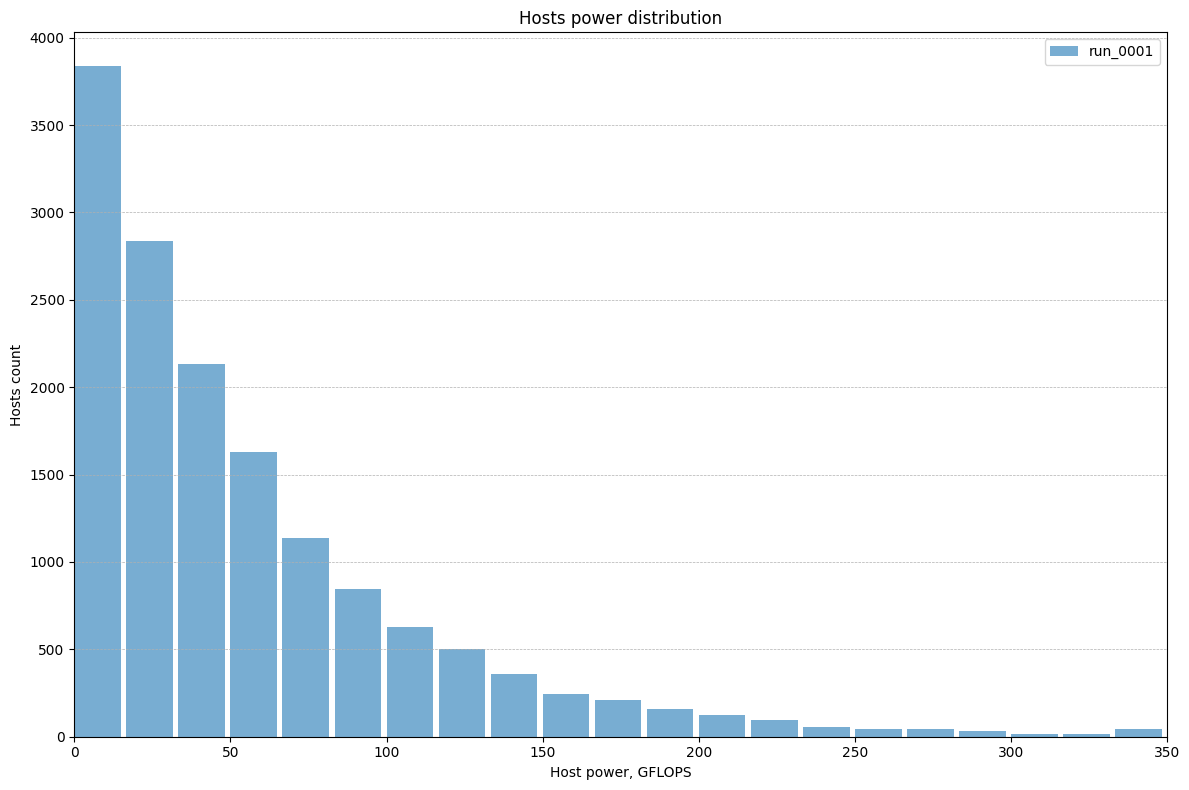

In [8]:
folders = sorted(
    folder
    for folder in os.listdir(STAT_PATH)
    if os.path.isdir(os.path.join(STAT_PATH, folder)) and folder.startswith(EXP_NAME)
)

if not folders:
    print(f"there is no folders in {STAT_PATH}")
else:
    print(f"found {folders}")

datasets = []

for folder in folders:
    full_path = os.path.join(STAT_PATH, folder)
    speed_statistics_path = os.path.join(full_path, SPEED_STATISTICS_NAME)

    if not os.path.exists(speed_statistics_path):
        print(f"skip {folder}: {SPEED_STATISTICS_NAME} not found")
        continue

    values = read_hosts_power(speed_statistics_path)
    if values.empty:
        print(f"skip {folder}: {SPEED_STATISTICS_NAME} is empty")
        continue

    datasets.append((folder, values))

if not datasets:
    print("there is no speed statistics to plot")
else:
    max_power = max(values.max() for _, values in datasets)
    fig, ax = plt.subplots(figsize=(12, 8))

    for folder, values in datasets:
        counts = build_power_counts(values, POWER_BIN_WIDTH, max_power)
        plot_hosts_power(ax, counts, folder, POWER_BIN_WIDTH)

    configure_power_axis(ax, max_power)
    ax.legend()
    plt.tight_layout()
    plt.show()
